# Slow SW Fit

Minimal notebook for loading ACE-at-Earth solar-wind data.

In [36]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = None
for candidate in (cwd, *cwd.parents, Path("/home/smdc/helio-n")):
    if (candidate / "Library").exists() and (candidate / "Config").exists():
        project_root = candidate
        break
assert (
    project_root is not None
), "Could not locate the helio-n project root for notebook imports."
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from Library.SW.Inputs import load_ace_at_earth
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [61]:
df_ace_earth = load_ace_at_earth()
df_ace_earth

,v_ace
date,
2010-08-01 00:00:00,526.025000
2010-08-01 01:00:00,521.029167
2010-08-01 02:00:00,524.886667
2010-08-01 03:00:00,528.753333
2010-08-01 04:00:00,521.786667
...,...
2023-12-31 16:00:00,299.126744
2023-12-31 21:00:00,317.418421
2023-12-31 22:00:00,319.443103


In [ ]:
df_ace_earth_slow = df_ace_earth.loc[df_ace_earth.v_ace <= 400].dropna()

In [ ]:
ydata = df_ace_earth_slow["v_ace"].to_numpy()
ydata

array([388.47944444, 394.95805556, 397.7875    , ..., 317.41842105,
       319.44310345, 319.16666667])

In [ ]:
xdata = (
    (df_ace_earth_slow.index - df_ace_earth_slow.index[0]) / pd.Timedelta("1h")
).to_numpy()
xdata

array([0.00000e+00, 1.00000e+00, 2.00000e+00, ..., 1.17463e+05,
       1.17464e+05, 1.17465e+05])

In [67]:
def func(xdata, k, b):
    return k * xdata + b

In [ ]:
def func(xdata, a, b, c):
    return a * xdata**2 + b * xdata + c

In [69]:
xfine = np.linspace(xdata.min(), xdata.max(), 100)

In [ ]:
popt, pcov = curve_fit(func, xdata, ydata)

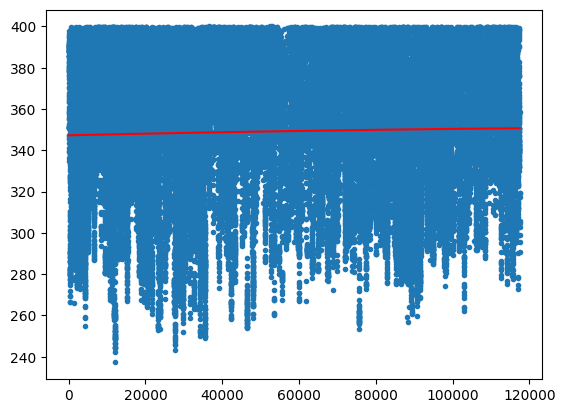

In [ ]:
plt.plot(xdata, ydata, ".")
plt.plot(xfine, func(xfine, *popt), "r-")

In [72]:
popt

array([-1.00232789e-10,  4.08826064e-05,  3.47289565e+02])

<Axes: xlabel='date'>

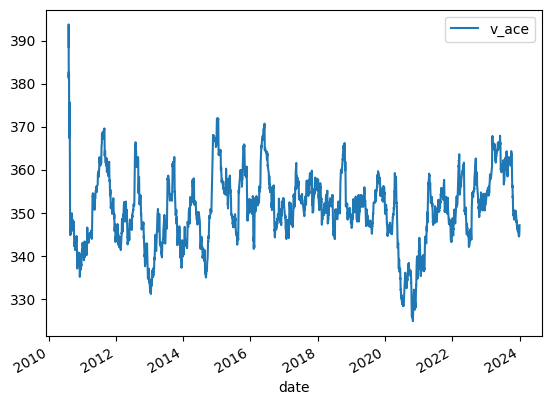

In [74]:
df_ace_earth_slow.rolling(str(27 * 3) + "d").mean().plot()

In [84]:
df_ace_earth_slow["2010":"2026"].mean()

v_ace    349.178029
dtype: float64

In [78]:
from Library.ICME import drop_icme_periods

In [89]:
drop_icme_periods(df_ace_earth_slow["2010":"2026"]).mean()

v_ace    348.217278
dtype: float64